In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.append("..")
sys.path.append("../..")

from smolagents import CodeAgent, HfApiModel, load_tool, tool
import random
import yaml
import PIL
import numpy as np
import torchvision.transforms as T

import torch

from agents.utils import export_masks, FinalAnswerTool
from agents.tools.reid import ReIDTool
from agents.tools.inpainting import InpaintingTool
from agents.tools.segmentation import SemanticSegmentationTool
from agents.tools.transmission import EncodingTool

from src.kitti_tracking_hf import KittiHFIterableDataset

from matplotlib import pyplot as plt

/home/leonard/anaconda3/envs/agentic/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/leonard/anaconda3/envs/agentic/lib/python3.10/site-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


In [3]:
root_dir = "/mnt/ssd/kitti_tracking"
n_steps, n_pred_steps = 8, 0

dataset_builder = KittiHFIterableDataset(
	root_dir=root_dir,
	split="training",
	n_steps=n_steps,
	n_pred_steps=n_pred_steps,
	transform=T.Compose([
		T.Resize((120, 320)),
	])
)
dataset = dataset_builder.to_hf_dataset()
for i, sample in enumerate(dataset):
    frames = sample['rgb']
    break

In [4]:
def gen_mask(f, _w=100, _h=100):
	w, h = f.size
	x, y = random.randint(0, w - _w), random.randint(0, h - _h)
	mask = torch.ones(1, 1, 1, h, w)
	return mask

model = HfApiModel(
	max_tokens=4906,
	temperature=0.5,
	model_id="meta-llama/Meta-Llama-3-8B-Instruct",
	custom_role_conversions=None,
)

with open("./vision.yaml", 'r') as stream:
	prompt_templates = yaml.safe_load(stream)

inpainting_tool = InpaintingTool(ckpt='../../checkpoints/dstt.pth')
semantic_segmentation_tool = SemanticSegmentationTool(model_name="CIDAS/clipseg-rd64-refined")
reid_tool = ReIDTool(0.5, model_name="kadirnar/osnet_x0_25_imagenet")
final_answer = FinalAnswerTool()

agent = CodeAgent(
	model=model,
	tools=[
		inpainting_tool,
		reid_tool,
		semantic_segmentation_tool,
		export_masks,
		final_answer,
	],
	additional_authorized_imports=["matplotlib", "PIL", "typing"],
	max_steps=1,
	verbosity_level=2,
	grammar=None,
	planning_interval=None,
	name=None,
	description=None,
	prompt_templates=prompt_templates,
)

interpreter_output = "Autonomous driving."
prompt = "vehicles, cars, pedestrians, cyclists, and road areas".split(", ")

In [ ]:
from smolagents import ActionStep

# Run vision expert ONCE on a sample to determine the processing pipeline
sample_frame = frames[0].resize((432, 240))
sample_mask_t = gen_mask(sample_frame)
sample_mask = PIL.Image.fromarray(255 * sample_mask_t[0, 0, 0].numpy().astype(np.uint8), "L")

agent.state.update({
	"rgb_frame": sample_frame,  # a placeholder
	"rgb_mask": sample_mask,  # a placeholder
	"depth_frame": sample_frame,  # a placeholder
	"depth_mask": sample_mask,  # a placeholder
	"object_classes": prompt,  # this from interpreter
})

agent.run(interpreter_output)

# Extract the generated code from the last ActionStep
pipeline_code = next(
	step.tool_calls[0].arguments
	for step in reversed(agent.logs)
	if isinstance(step, ActionStep) and step.tool_calls
)
print("Generated pipeline:\n", pipeline_code)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Autonomous driving.                                                                                             │
│                                                                                                                 │
╰─ HfApiModel - meta-llama/Meta-Llama-3-8B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Task: Autonomous driving.                                                                                          
                                                                                                                   
Thought: The robotic application is autonomous driving. It requires sensing data from RGB and depth modalities.    
The object classes of interest are: vehicles, pedestrians, cyclists, and road areas.                               
I need to identify the regions of intersted object classes and extract depth information of those regions.         
I will first reconstruct the RGB. Then detect semantic masks of the interested object classes.                     
Since the depth measurement is corresponding to the semantic mask, I use the semantic mask from RGB modality as the
same as mask for depth image.                                                                                      
                                                                                                                   
Code:                                                                                                              
```py                                                                                                              
recon_rgb_frame = inpainting_tool(image=rgb_frame, mask=rgb_mask)                                                  
sem_rgb_mask = semantic_segmentation_tool(frame=recon_rgb_frame, prompt=["vehicles", "pedestrians", "cyclists",    
"road areas"])                                                                                                     
sem_depth_mask = sem_rgb_mask.copy()                                                                               
final_answer([sem_rgb_mask, sem_depth_mask])                                                                       
```<end_code>                                                                                                      

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  recon_rgb_frame = inpainting_tool(image=rgb_frame, mask=rgb_mask)                                                
  sem_rgb_mask = semantic_segmentation_tool(frame=recon_rgb_frame, prompt=["vehicles", "pedestrians", "cyclists",  
  "road areas"])                                                                                                   
  sem_depth_mask = sem_rgb_mask.copy()                                                                             
  final_answer([sem_rgb_mask, sem_depth_mask])                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Unused or unrecognized kwargs: padding, truncation.


Out - Final answer: [<PIL.Image.Image image mode=L size=432x240 at 0x7DB5375946D0>, <PIL.Image.Image image mode=L 
size=432x240 at 0x7DB527BA73D0>]

[Step 1: Duration 8.02 seconds| Input tokens: 2,148 | Output tokens: 186]

The 'logs' attribute is deprecated and will soon be removed. Please use 'self.memory.steps' instead.


Generated pipeline:
 recon_rgb_frame = inpainting_tool(image=rgb_frame, mask=rgb_mask)
sem_rgb_mask = semantic_segmentation_tool(frame=recon_rgb_frame, prompt=["vehicles", "pedestrians", "cyclists", "road areas"])
sem_depth_mask = sem_rgb_mask.copy()
final_answer([sem_rgb_mask, sem_depth_mask])


In [6]:
import re

def build_pipeline(code_str, **tools):
	"""Compile agent-generated pipeline code into a reusable callable."""
	body = re.sub(r'\bfinal_answer\((.+)\)', r'__result__ = \1', code_str, flags=re.DOTALL)

	def pipeline(rgb_frame=None, rgb_mask=None, depth_frame=None, depth_mask=None, object_classes=None):
		ns = {
			**tools,
			"rgb_frame": rgb_frame,
			"rgb_mask": rgb_mask,
			"depth_frame": depth_frame,
			"depth_mask": depth_mask,
			"object_classes": object_classes,
			"__result__": None,
		}
		exec(body, ns)
		return ns["__result__"]

	return pipeline

pipeline = build_pipeline(
	pipeline_code,
	inpainting_tool=inpainting_tool,
	semantic_segmentation_tool=semantic_segmentation_tool,
	reid_tool=reid_tool,
)
print("Pipeline ready.")

Pipeline ready.


In [7]:
# Apply pipeline to all frames — vision expert is NOT invoked again
results = []
for frame in frames:
	_frame = frame.resize((432, 240))
	mask_t = gen_mask(_frame)
	mask = PIL.Image.fromarray(255 * mask_t[0, 0, 0].numpy().astype(np.uint8), "L")

	masks = pipeline(
		rgb_frame=_frame,
		rgb_mask=mask,
		depth_frame=_frame,
		depth_mask=mask,
		object_classes=prompt,
	)
	results.append(masks)

print(f"Processed {len(results)} frames")

Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.
Unused or unrecognized kwargs: padding, truncation.


Processed 8 frames


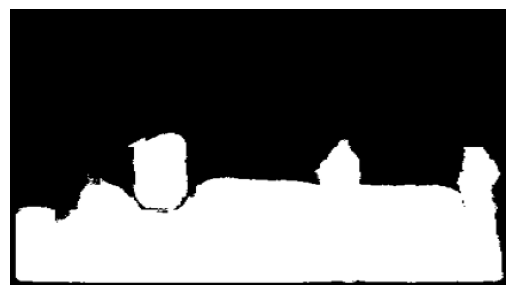

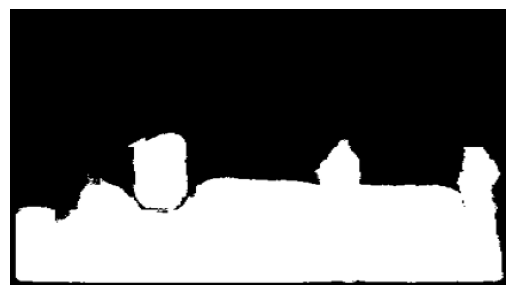

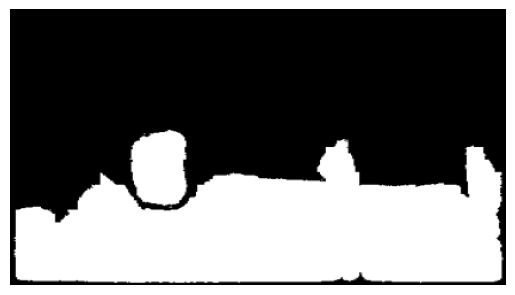

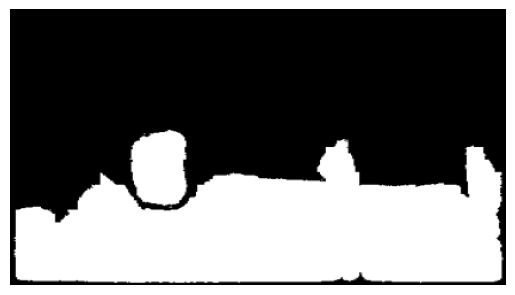

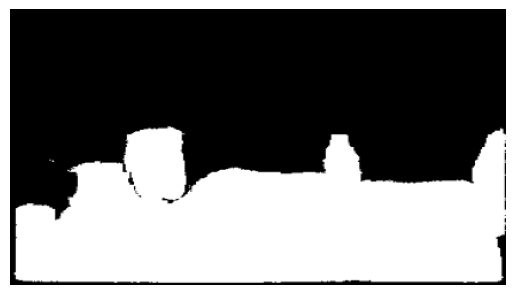

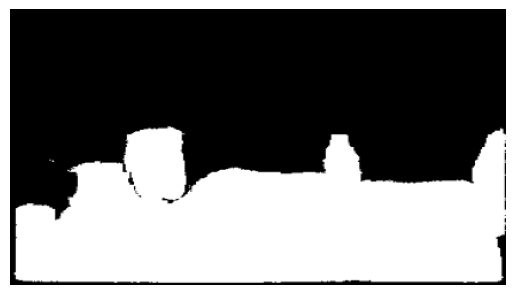

In [8]:
for masks in results[:3]:
	for mask in masks:
		plt.imshow(mask, cmap="grey")
		plt.axis("off")
		plt.show()